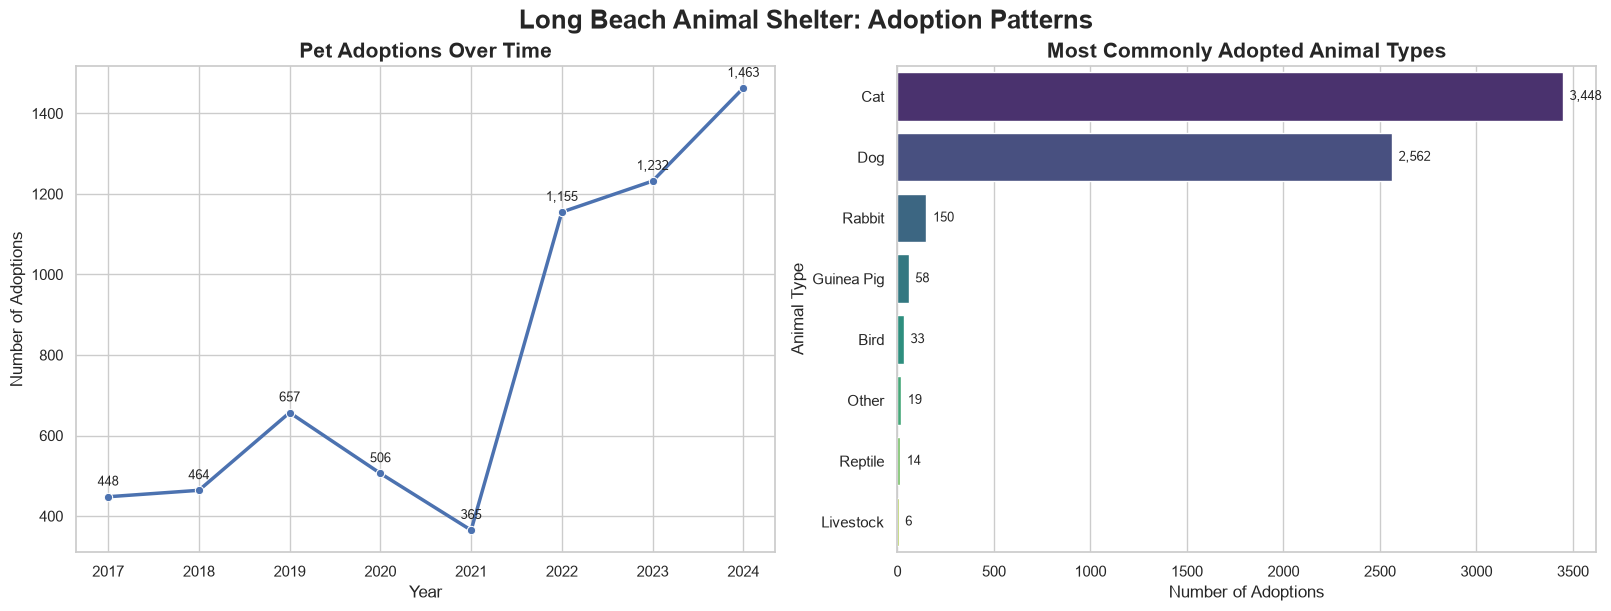

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Load Long Beach Animal Shelter data
# ============================================================

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-03-04/longbeach.csv"

df = pd.read_csv(
    url,
    parse_dates=["dob", "intake_date", "outcome_date"]
)

# ============================================================
# Clean data
# ============================================================

df["outcome_type"] = (
    df["outcome_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df["animal_type"] = (
    df["animal_type"]
    .fillna("Unknown")
    .astype(str)
    .str.title()
)

# ============================================================
# Filter to adoptions
# IMPORTANT: the dataset uses "adoption", not "adopted"
# ============================================================

adoptions = df[
    df["outcome_type"] == "adoption"
].copy()

# Extract adoption year
adoptions["year"] = (
    pd.to_datetime(adoptions["outcome_date"], errors="coerce")
    .dt.year
)

# ============================================================
# Count adoptions by year
# ============================================================

yearly_adoptions = (
    adoptions
    .dropna(subset=["year"])
    .groupby("year")
    .size()
    .reset_index(name="adoptions")
    .sort_values("year")
)

# ============================================================
# Count adoptions by animal type
# ============================================================

animal_adoptions = (
    adoptions["animal_type"]
    .value_counts()
    .rename_axis("animal_type")
    .reset_index(name="adoptions")
    .sort_values("adoptions", ascending=False)
)

# ============================================================
# Plot
# ============================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    constrained_layout=True
)

# ------------------------------------------------------------
# Left: Adoptions over time
# ------------------------------------------------------------

sns.lineplot(
    data=yearly_adoptions,
    x="year",
    y="adoptions",
    marker="o",
    linewidth=2.5,
    ax=axes[0]
)

axes[0].set_title(
    "Pet Adoptions Over Time",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Adoptions")

# Add values to line
for _, row in yearly_adoptions.iterrows():
    axes[0].annotate(
        f"{int(row['adoptions']):,}",
        (row["year"], row["adoptions"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# ------------------------------------------------------------
# Right: Most adopted animal types
# ------------------------------------------------------------

top_animals = animal_adoptions.head(10)

sns.barplot(
    data=top_animals,
    x="adoptions",
    y="animal_type",
    hue="animal_type",
    palette="viridis",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Most Commonly Adopted Animal Types",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Number of Adoptions")
axes[1].set_ylabel("Animal Type")

# Add values to bars
for i, value in enumerate(top_animals["adoptions"]):
    axes[1].text(
        value + max(top_animals["adoptions"]) * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=9
    )

# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    "Long Beach Animal Shelter: Adoption Patterns",
    fontsize=19,
    fontweight="bold"
)

plt.show()